"""
STEP 2 (OPTIMIZED): Seam Carving Text Line Segmentation
========================================================
This is an improved version of the  optimal_seam carving 3 script.

IMPROVEMENTS OVER THE ORIGINAL:
  1. BETTER BINARIZATION: Replaced the otsu threshold with
     adaptive thresholding method, which is useful when lighting conditions vary across the image — instead of one global threshold, it calculates thresholds for small regions.
     This is more robust to yellowed or stained manuscript pages.

  2. VECTORIZED DYNAMIC PROGRAMMING: this is still the same This version uses NumPy vectorization
     to compute the entire DP table column-by-column without any Python loops
     over rows. This gives a 10–50x speedup on typical images.

  3. DESKEWING: Added an optional skew correction step using the Hough transform.
     Slightly tilted pages cause the projection profile to smear, making valley
     detection harder. Correcting the skew first improves line detection.

  4. MORPHOLOGICAL CLOSING: Before computing the projection profile, a horizontal
     morphological closing operation is applied to the binary image. This connects
     broken strokes within the same line, making the profile peaks sharper and
     the valleys deeper — easier to detect.

  5. ADAPTIVE PADDING: Instead of a fixed padding, the line height is estimated
     from the projection profile and the padding is set proportionally.

  6. PROGRESS LOGGING: Saves a CSV summary of all processed images with the
     number of lines detected per image.

References:
  - Das & Panda (2023). "Seam carving, horizontal projection profile and contour
    tracing for line and word segmentation." Results in Engineering.
    https://doi.org/10.1016/j.rineng.2023.101282
  - Avidan & Shamir (2007). "Seam Carving for Content-Aware Image Resizing."
    ACM SIGGRAPH. https://doi.org/10.1145/1275808.1276390
  - Kurar Barakat et al. (2020). "Learning-Free Text Line Segmentation for
    Historical Handwritten Documents." Applied Sciences.
    https://doi.org/10.3390/app10228276
"""

In [1]:
import os
from turtle import up
import cv2
import numpy as np
import csv
import matplotlib
#matplotlib.use('Agg')
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d
from scipy.signal import find_peaks
from tqdm import tqdm

In [2]:
# ============================================================
# SETTINGS - Change these paths to match your computer
# ============================================================

INPUT_FOLDER = r'C:\Users\pmlma\.vscode\Math_804_transcription_project\word-segmentation-proj\cropped_case_and_ayer_imgs'
OUTPUT_FOLDER = r'C:\Users\pmlma\.vscode\Math_804_transcription_project\word-segmentation-proj\seam_carved_line_images6_case_and_ayer_imgs'


In [41]:
# --- Preprocessing ---
# Apply morphological closing to connect broken strokes before profiling.
# This makes valleys deeper and easier to detect. Recommended: True.
USE_MORPHOLOGICAL_CLOSING = True

# Width of the horizontal structuring element for closing (in pixels).
# Larger = connects more broken strokes, but may merge nearby lines.
# Typical range: 20–60 pixels. Default: 40.
CLOSING_WIDTH = 38

# Apply skew correction before segmentation.
# Set to True if your images have visibly tilted text lines.
USE_DESKEW = True

# --- Gap Detection ---
# Gaussian smoothing sigma for the projection profile.
SMOOTHING_SIGMA = 3

# Minimum distance (pixels) between consecutive seams ≈ minimum line height.
MIN_LINE_DISTANCE = 20

# Minimum valley prominence for detection.
VALLEY_PROMINENCE = 3

# --- Seam Carving ---
# Search band half-width (pixels). The seam can deviate this far from the valley.
SEAM_SEARCH_BAND = 8

# --- Output ---
MIN_LINE_HEIGHT = 15
LINE_PADDING    = 0
SAVE_VISUALIZATION = True

# ============================================================
# BINARIZATION FUNCTIONS
# ============================================================


In [5]:
def binarize_for_cc(gray):
    clahe = cv2.createCLAHE(clipLimit=3.3, tileGridSize=(8, 8))
    enhance = clahe.apply(gray)
    blurred = cv2.GaussianBlur(enhance, (3, 3), 0)

    binary = cv2.adaptiveThreshold(
        blurred,
        255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY_INV,
        31,
        12
    )

    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 1))
    binary = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel)

    return binary

In [6]:
%matplotlib inline

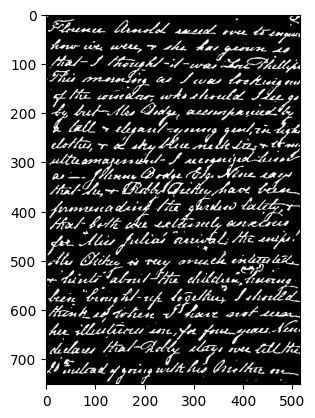

In [8]:
path1 = r'cropped_case_and_ayer_imgs\995745818805867_case_ms_4a_31_004-1.jpg'

img1 = cv2.imread(path1, cv2.IMREAD_GRAYSCALE)
if img1 is None:
    print("Image not found. Check the file path.")
else:
    plt.imshow(binarize_for_cc(img1), cmap='gray')
    plt.show()
    

In [9]:
# ============================================================
# DESKEWING
# ============================================================

def estimate_skew_angle(binary_image, angle_range=(-10, 10)):
    """
    Estimates the skew angle of a document image using the Hough transform.

    The function finds the dominant line orientation in the binary image
    and returns the angle needed to correct it.

    Returns:
        angle (float): rotation angle in degrees to deskew the image
    """
    edges = cv2.Canny((binary_image * 255).astype(np.uint8), 50, 150)
    lines = cv2.HoughLinesP(
        edges,
        rho=1,
        theta=np.pi / 180,
        threshold=100,
        minLineLength=binary_image.shape[1] // 4,
        maxLineGap=20
    )
    if lines is None:
        return 0.0

    angles = []
    for line in lines:
        x1, y1, x2, y2 = line[0]
        if x2 != x1:
            angle = np.degrees(np.arctan2(y2 - y1, x2 - x1))
            if angle_range[0] <= angle <= angle_range[1]:
                angles.append(angle)

    if not angles:
        return 0.0

    return float(np.median(angles))


def deskew_image(image, angle):
    """
    Rotates an image by the given angle around its center.
    Fills empty corners with the mean background color.
    """
    if abs(angle) < 0.1:
        return image  # No correction needed

    h, w = image.shape[:2]
    center = (w // 2, h // 2)
    M = cv2.getRotationMatrix2D(center, angle, 1.0)

    # Use the mean border color as fill value
    border_color = int(image[0, :].mean())
    rotated = cv2.warpAffine(
        image, M, (w, h),
        flags=cv2.INTER_LINEAR,
        borderMode=cv2.BORDER_CONSTANT,
        borderValue=(border_color, border_color, border_color)
    )
    return rotated




In [10]:
# ============================================================
# PREPROCESSING
# ============================================================

def preprocess_image(image_path):
    """
    Loads, optionally deskews, and binarizes the image.

    Returns:
        original: color image (H, W, 3) — used for final line extraction
        binary:   binary image (H, W), 1=ink, 0=background
    """
    original = cv2.imread(image_path)
    if original is None:
        raise FileNotFoundError(f"Could not load image: {image_path}")

    gray = cv2.cvtColor(original, cv2.COLOR_BGR2GRAY)

    # Optional deskewing
    if USE_DESKEW:
        temp_binary = binarize_for_cc(gray)
        angle = estimate_skew_angle(temp_binary)
        if abs(angle) > 0.1:
            original = deskew_image(original, angle)
            gray = cv2.cvtColor(original, cv2.COLOR_BGR2GRAY)

    # Binarization

        binary = binarize_for_cc(gray)

    return original, binary

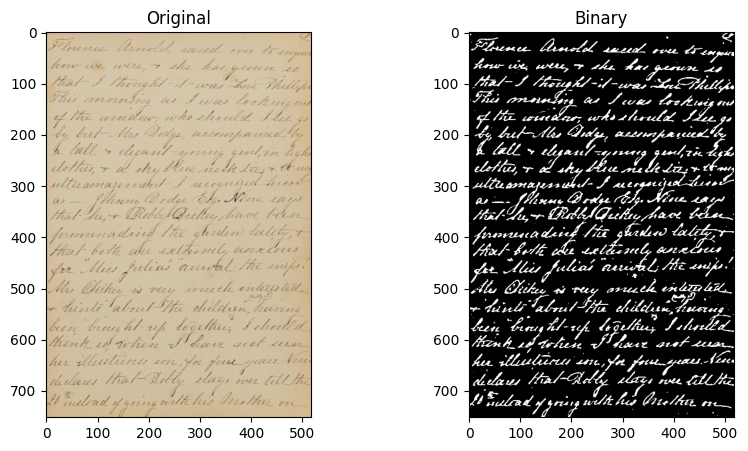

In [21]:
original, binary = preprocess_image(path1)
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(cv2.cvtColor(original, cv2.COLOR_BGR2RGB))
axes[0].set_title('Original')
axes[1].imshow(binary, cmap='gray')
axes[1].set_title('Binary')
plt.show()

In [22]:
# ============================================================
# MORPHOLOGICAL CLOSING (IMPROVEMENT 4)
# ============================================================

def apply_morphological_closing(binary_image, closing_width):
    """
    Applies horizontal morphological closing to the binary image.

    Closing = dilation followed by erosion with a horizontal structuring element.
    Effect: connects broken strokes within the same text line horizontally,
    making the projection profile peaks taller and valleys deeper.

    This is a key improvement for manuscripts where ink strokes are fragmented
    due to paper degradation or faded ink.

    Reference:
        Gonzalez & Woods (2018). "Digital Image Processing." 4th ed. Pearson.
    """
    kernel = cv2.getStructuringElement(
        cv2.MORPH_RECT,
        (closing_width, 1)  # Horizontal kernel: wide but 1 pixel tall
    )
    closed = cv2.morphologyEx(
        (binary_image * 255).astype(np.uint8),
        cv2.MORPH_CLOSE,
        kernel
    )
    return (closed > 0).astype(np.uint8)

In [23]:
# ============================================================
# PROJECTION PROFILE & VALLEY DETECTION
# ============================================================
def refine_valleys_to_low_ink_rows(binary_image, valleys, window=8):
    refined = []
    h = binary_image.shape[0]
    row_sums = binary_image.sum(axis=1)

    for v in valleys:
        a = max(0, v - window)
        b = min(h, v + window + 1)
        local = row_sums[a:b]
        best = a + int(np.argmin(local))
        refined.append(best)

    return refined

In [38]:
def find_line_boundaries(binary_image, smoothing_sigma, min_distance, prominence):
    """
    Finds valley positions in the horizontal projection profile.

    Optionally applies morphological closing first to sharpen the profile.

    Returns:
        valleys:  list of y-coordinates for seam placement
        profile:  raw ink-count-per-row array
        smoothed: smoothed profile
    """
    # Apply morphological closing to sharpen the profile
    if USE_MORPHOLOGICAL_CLOSING:
        profile_binary = apply_morphological_closing(binary_image, CLOSING_WIDTH)
    else:
        profile_binary = binary_image

    profile = profile_binary.sum(axis=1).astype(float)
    smoothed = gaussian_filter1d(profile, sigma=smoothing_sigma)

    height = binary_image.shape[0]
    valleys, _ = find_peaks(-smoothed, prominence=prominence, distance=min_distance)
    valleys = [int(v) for v in valleys if 15 < v < height - 15]
    valleys = refine_valleys_to_low_ink_rows(binary_image, valleys, window=8)

   # TOP_IGNORE = 50 # can tune 30,40,50
   # valleys = [v for v in valleys if v > TOP_IGNORE]
    return valleys, profile, smoothed


In [ ]:
valley1, profile1, smoothed1= find_line_boundaries(preprocess_image(path1)[1], SMOOTHING_SIGMA, MIN_LINE_DISTANCE, VALLEY_PROMINENCE)
valley1

In [28]:
# ============================================================
# ENERGY MAP
# ============================================================


def compute_energy_map(binary_image):
    """
    Computes the seam energy map from the binary image.

    Energy = 1000 × ink_pixel + |gradient_y| + |gradient_x|

    The large constant (1000) strongly penalizes ink pixels so the seam
    avoids them. The gradient terms add a small additional penalty near
    ink edges, helping the seam stay in clear background regions.
    """
    energy = binary_image.astype(float) * 1500.0
    gy = np.abs(np.gradient(binary_image.astype(float), axis=0))
    gx = np.abs(np.gradient(binary_image.astype(float), axis=1))
    energy += gy + gx

    h, w = binary_image.shape

    # penalize left/right margins to stop seams from escaping into dark borders
    margin = 25
    edge_penalty = 200.0
    energy[:, :margin] += edge_penalty
    energy[:, w - margin:] += edge_penalty
    
    return energy

In [29]:
# ============================================================
# VECTORIZED SEAM CARVING (IMPROVEMENT 2)
# ============================================================

def find_horizontal_seam_fast(energy_map, start_row, search_band):
    """
    Finds the minimum-energy horizontal seam using VECTORIZED dynamic programming.

    IMPROVEMENT over the original:
        The original used nested Python for-loops (O(width × band_height) Python
        operations). This version processes each column with NumPy operations,
        eliminating the inner Python loop over rows. This is 10–50x faster.

    Algorithm:
        For each column j from left to right:
          dp[i, j] = energy[i, j] + min(dp[i-1, j-1], dp[i, j-1], dp[i+1, j-1])
        
        This is computed using np.roll and np.minimum instead of a Python loop.

    Parameters:
        energy_map:  2D float array of pixel energies
        start_row:   approximate y-coordinate for the seam
        search_band: half-width of the search band in pixels

    Returns:
        seam: 1D int array of length = image width, seam[x] = y-coordinate
    """
    height, width = energy_map.shape
    row_min = max(0, start_row - search_band)
    row_max = min(height - 1, start_row + search_band)
    band_h  = row_max - row_min + 1

    if band_h <= 0:
        return np.full(width, start_row, dtype=int)

    sub_energy = energy_map[row_min:row_max + 1, :].copy()
    dp         = sub_energy.copy()
    backtrack  = np.zeros((band_h, width), dtype=np.int32)

    for j in range(1, width):
        prev_col = dp[:, j - 1]

       # predecessor options for current row i:
       # prev row i-1, prev row i, prev row i+1

        up   = np.roll(prev_col,  1)   # row i-1
        up[0] = np.inf

        same = prev_col                # row i

        down = np.roll(prev_col, -1)   # row i+1
        down[-1] = np.inf

        penalty = 1.0   # try 1.5 → 5.0

        stacked = np.stack([
        up   + penalty,   # moving up
        same,             # staying same
        down + penalty    # moving down
        ], axis=0)
        best_dir = np.argmin(stacked, axis=0)
        min_prev = stacked[best_dir, np.arange(band_h)]

        dp[:, j] = sub_energy[:, j] + min_prev

        # map chosen predecessor to actual predecessor row index
        offsets = np.array([-1, 0, 1], dtype=np.int32)
        backtrack[:, j] = np.arange(band_h) + offsets[best_dir]
        backtrack[:, j] = np.clip(backtrack[:, j], 0, band_h - 1)
    # Traceback from right to left
    seam = np.zeros(width, dtype=int)
    seam[width - 1] = int(np.argmin(dp[:, width - 1]))
    for j in range(width - 2, -1, -1):
        seam[j] = backtrack[seam[j + 1], j + 1]

    return seam + row_min


In [43]:
def estimate_background_color(original_image):
    """
    Estimate manuscript paper background from image borders.
    """
    border_pixels = np.vstack([
        original_image[:20, :, :].reshape(-1, 3),
        original_image[-20:, :, :].reshape(-1, 3),
        original_image[:, :20, :].reshape(-1, 3),
        original_image[:, -20:, :].reshape(-1, 3),
    ])

    return np.median(border_pixels, axis=0).astype(np.uint8)

In [ ]:
# ============================================================
# LINE EXTRACTION
# ============================================================

def extract_lines_with_seams_following_paths(original_image, seams, padding=5, min_height=15):
    """
    Extract line bands by following the seam paths column-by-column
    instead of using one global rectangular crop.
    """
    h, w = original_image.shape[:2]
    line_images = []

    top_seam = np.zeros(w, dtype=int)
    bottom_seam = np.full(w, h - 1, dtype=int)
    all_seams = [top_seam] + seams + [bottom_seam]

    for i in range(len(all_seams) - 1):
        upper = np.clip(all_seams[i] - padding, 0, h - 1)
        lower = np.clip(all_seams[i + 1] + padding, 0, h - 1)

        # ensure valid band
        band_heights = lower - upper + 1
        if np.median(band_heights) < min_height:
            continue

        y0 = int(np.min(upper))
        y1 = int(np.max(lower))
        
        bg_color = estimate_background_color(original_image)
        strip = np.full((y1 - y0 + 1, w, 3), bg_color, dtype=np.uint8)

        for x in range(w):
            top = upper[x]
            bot = lower[x]
            if bot >= top:
                strip[(top - y0):(bot - y0 + 1), x] = original_image[top:bot + 1, x]

        # optional: crop away blank rows after masking
        gray = cv2.cvtColor(strip, cv2.COLOR_BGR2GRAY)
        ink_rows = np.where(gray < 245)[0]
        if len(ink_rows) == 0:
            continue

        r0, r1 = ink_rows[0], ink_rows[-1]
        final_strip = strip[r0:r1 + 1, :]

        if final_strip.shape[0] >= min_height:
            line_images.append(final_strip)

    return line_images


In [31]:
# ============================================================
# VISUALIZATION
# ============================================================

def save_seam_visualization(original_image, seams, output_path):
    """Draws colored seams on the original image and saves it."""
    vis = original_image.copy()
    colors = [
        (0, 0, 255), (0, 165, 255), (0, 255, 0),
        (255, 0, 0), (255, 0, 255), (0, 255, 255), (128, 0, 128)
    ]
    for si, seam in enumerate(seams):
        color = colors[si % len(colors)]
        for x, y in enumerate(seam):
            for dy in range(-1, 2):
                if 0 <= y + dy < vis.shape[0]:
                    vis[y + dy, x] = color
    cv2.imwrite(output_path, vis)


In [32]:
# ============================================================
# MAIN PROCESSING FUNCTION
# ============================================================
def smooth_seams_with_neighbors(seams):
    """
    Smooth each seam using its immediate neighbors.
    """
    if len(seams) < 3:
        return seams

    smoothed = []
    for i in range(len(seams)):
        if i == 0 or i == len(seams) - 1:
            smoothed.append(seams[i].copy())
        else:
            s = (
                0.25 * seams[i - 1].astype(np.float32) +
                0.50 * seams[i].astype(np.float32) +
                0.25 * seams[i + 1].astype(np.float32)
            )
            smoothed.append(np.round(s).astype(np.int32))
    return smoothed




In [33]:
def process_single_image(image_path, output_dir):
    """
    Full pipeline for one image: preprocess → detect valleys →
    compute energy → carve seams → extract lines → save.

    Returns the number of text lines extracted.
    """
    base_name = os.path.splitext(os.path.basename(image_path))[0]
    img_out_dir = os.path.join(output_dir, base_name)
    os.makedirs(img_out_dir, exist_ok=True)

    original, binary = preprocess_image(image_path)

    valleys, profile, smoothed = find_line_boundaries(
        binary,
        smoothing_sigma=SMOOTHING_SIGMA,
        min_distance=MIN_LINE_DISTANCE,
        prominence=VALLEY_PROMINENCE
    )

    if not valleys:
        print(f"\n  WARNING: No gaps found in '{base_name}'.")
        print("  Try lowering VALLEY_PROMINENCE or MIN_LINE_DISTANCE.")
        return 0

    energy_map = compute_energy_map(binary)

    seams = [
    find_horizontal_seam_fast(energy_map, v, search_band=SEAM_SEARCH_BAND)
    for v in valleys
    ]
    seams = smooth_seams_with_neighbors(seams)
    line_images = extract_lines_with_seams_following_paths(
    original, seams, padding=LINE_PADDING, min_height=MIN_LINE_HEIGHT
    )

    for idx, line_img in enumerate(line_images):
        out_path = os.path.join(img_out_dir, f"{base_name}_line_{idx + 1:03d}.jpg")
        cv2.imwrite(out_path, line_img, [cv2.IMWRITE_JPEG_QUALITY, 95])

    if SAVE_VISUALIZATION:
        viz_path = os.path.join(img_out_dir, f"{base_name}_seams.jpg")
        save_seam_visualization(original, seams, viz_path)

    return len(line_images)



In [35]:
outputpath= r'C:\Users\pmlma\.vscode\Math_804_transcription_project\word-segmentation-proj\seam_carved_line_images6_case_and_ayer_imgs_test'



In [45]:
process_single_image(path1, outputpath)

21

In [46]:
# ============================================================
# MAIN SCRIPT
# ============================================================

def main():
    os.makedirs(OUTPUT_FOLDER, exist_ok=True)

    supported_ext = ('.jpg', '.jpeg', '.png', '.tif', '.tiff')
    all_files = [
        f for f in sorted(os.listdir(INPUT_FOLDER))
        if f.lower().endswith(supported_ext)
    ]

    if not all_files:
        print(f"ERROR: No image files found in '{INPUT_FOLDER}'")
        return

    print(f"Found {len(all_files)} images.")
    print(f"Binarization: Adaptive Gaussian")
    print(f"Morphological closing: {'ON' if USE_MORPHOLOGICAL_CLOSING else 'OFF'}")
    print(f"Deskewing: {'ON' if USE_DESKEW else 'OFF'}")
    print("=" * 60)

    summary_rows = []
    total_lines  = 0
    failed       = []

    for filename in tqdm(all_files, desc="Segmenting"):
        image_path = os.path.join(INPUT_FOLDER, filename)
        try:
            n_lines = process_single_image(image_path, OUTPUT_FOLDER)
            total_lines += n_lines
            summary_rows.append({'image': filename, 'lines_detected': n_lines, 'status': 'OK'})
        except Exception as e:
            print(f"\n  ERROR: {filename}: {e}")
            failed.append(filename)
            summary_rows.append({'image': filename, 'lines_detected': 0, 'status': f'ERROR: {e}'})

    # Save summary CSV
    csv_path = os.path.join(OUTPUT_FOLDER, 'segmentation_summary.csv')
    with open(csv_path, 'w', newline='') as f:
        writer = csv.DictWriter(f, fieldnames=['image', 'lines_detected', 'status'])
        writer.writeheader()
        writer.writerows(summary_rows)

    print("=" * 60)
    print(f"Done. Processed {len(all_files) - len(failed)} images.")
    print(f"Total lines extracted: {total_lines}")
    print(f"Summary saved to: {csv_path}")
    if failed:
        print(f"Failed: {failed}")


if __name__ == "__main__":
    main()

Found 244 images.
Binarization: Adaptive Gaussian
Morphological closing: ON
Deskewing: ON


Segmenting: 100%|██████████| 244/244 [03:59<00:00,  1.02it/s]

Done. Processed 244 images.
Total lines extracted: 5459
Summary saved to: C:\Users\pmlma\.vscode\Math_804_transcription_project\word-segmentation-proj\seam_carved_line_images6_case_and_ayer_imgs\segmentation_summary.csv
